# WLS 标准化调试与可视化

调试 `_constrained_wls` 方法，并可视化回归结果

In [60]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 导入自定义模块
from data_preprocessing import FundDataPreprocessor
from fund_type_classifier import FundTypeClassifier
from wind_data_fetcher import WindDataFetcher
from bond_index_data import BondIndexDataProcessor
from duration_model import DurationModel

# 设置 matplotlib 中文显示
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 8)

print('模块导入成功')

模块导入成功


## 1. 初始化数据

In [61]:
print('='*60)
print('调试_constrained_wls方法')
print('='*60)

# 设置目标日期
target_date = '2026-06-12'

# 初始化各模块
preprocessor = FundDataPreprocessor(
    short_term_path='短期纯债基金样本数据.xlsx',
    medium_long_term_path='中长期纯债基金样本数据.xlsx'
)

classifier = FundTypeClassifier(holdings_path='纯债基金持仓情况.xlsx')
classifier.load_holdings_data()

wind_fetcher = WindDataFetcher()

index_processor = BondIndexDataProcessor(index_path='中债财富指数.xlsx')
index_processor.load_price_data()
index_processor.load_duration_data()

# 获取测试基金
fund_pool = preprocessor.get_fund_pool(target_date)
fund_df_short = fund_pool.get('short', pd.DataFrame())
test_fund = fund_df_short.iloc[1]
test_code = test_fund['Code']

print(f'\n测试基金: {test_code} - {test_fund["Name"]}')

调试_constrained_wls方法
Wind连接成功

测试基金: 000089.OF - 民生加银高等级信用债C


## 2. 获取数据并筛选因子

In [62]:
# 获取基金类型和指数
fund_bond_type = classifier.get_fund_type(test_code, target_date)
index_codes = index_processor.short_credit_indices

# 获取净值数据
start_date_calc = (pd.to_datetime(target_date) - pd.Timedelta(days=90)).strftime('%Y-%m-%d')
fund_nav_df = wind_fetcher.get_fund_nav_smoothed(test_code, start_date_calc, target_date)

# 模拟calculate_fund_duration的逻辑
end_date = pd.to_datetime(target_date)
start_date = end_date - pd.Timedelta(days=60)
fund_returns = fund_nav_df['return'].loc[start_date:end_date].dropna()
fund_returns = fund_returns.iloc[-30:]  # 只使用最近window个交易日

print(f'基金收益率（最近30个交易日）: {len(fund_returns)} 条')

index_prices = index_processor.get_index_prices(
    index_codes,
    start_date.strftime('%Y-%m-%d'),
    end_date.strftime('%Y-%m-%d')
)
index_returns = index_prices.pct_change().dropna()
print(f'指数收益率: {index_returns.shape}')

common_dates = fund_returns.index.intersection(index_returns.index)
print(f'共同日期: {len(common_dates)} 个')

fund_returns_aligned = fund_returns.loc[common_dates]
index_returns_aligned = index_returns.loc[common_dates]
print(f'对齐后基金收益率: {len(fund_returns_aligned)}')
print(f'对齐后指数收益率: {index_returns_aligned.shape}')

# 检查_lasso_select_factors
print('\n检查Lasso筛选...')
model = DurationModel(index_processor)
selected_factors = model._lasso_select_factors(fund_returns_aligned, index_returns_aligned)
print(f'选中的因子: {selected_factors}')

index_returns_selected = index_returns_aligned[selected_factors]
print(f'筛选后的指数收益率: {index_returns_selected.shape}')

# 检查时间权重
time_weights = model._get_time_weights(len(fund_returns_aligned))
print(f'时间权重: {len(time_weights)} 个（总和={time_weights.sum():.4f}）')

基金收益率（最近30个交易日）: 30 条
指数收益率: (41, 5)
共同日期: 30 个
对齐后基金收益率: 30
对齐后指数收益率: (30, 5)

检查Lasso筛选...
选中的因子: ['CBA01861.CS', 'CBA02821.CS']
筛选后的指数收益率: (30, 2)
时间权重: 30 个（总和=15.5000）


## 3. 数据对齐检查

In [63]:
print('\n' + '='*60)
print('【关键调试】检查_constrained_wls内部的对齐问题...')
print('='*60)

# 模拟_constrained_wls内部的对齐过程
aligned_data_internal = pd.DataFrame({
    'fund': fund_returns_aligned
}).join(index_returns_selected, how='inner').dropna()

print(f'对齐后数据形状: {aligned_data_internal.shape}')

if len(aligned_data_internal) != len(time_weights):
    print(f'❌ 数据长度({len(aligned_data_internal)}) != 权重长度({len(time_weights)})')
else:
    print(f'✓ 数据长度匹配: {len(aligned_data_internal)}')

# 生成正确的权重
correct_time_weights = model._get_time_weights(len(aligned_data_internal))
print(f'正确的权重长度: {len(correct_time_weights)}')


【关键调试】检查_constrained_wls内部的对齐问题...
对齐后数据形状: (30, 3)
✓ 数据长度匹配: 30
正确的权重长度: 30


## 4. 标准化与条件数分析

In [64]:
X = aligned_data_internal.iloc[:, 1:].values
y = aligned_data_internal['fund'].values
n_factors = X.shape[1]

print(f'\n1. 数据矩阵信息:')
print(f'   X形状: {X.shape} (观测数 x 因子数)')
print(f'   y形状: {y.shape}')

# 标准化数据
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_std = scaler_X.fit_transform(X)
y_std = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

X_scale = scaler_X.scale_
y_scale = scaler_y.scale_[0]

print(f'\n   标准化后 X_std 形状: {X_std.shape}')
print(f'   X 各因子标准差: {X_scale}')
print(f'   y 标准差: {y_scale:.6f}')

# 条件数分析
from numpy.linalg import cond
XtWX_original = X.T @ np.diag(correct_time_weights) @ X
XtWX_std = X_std.T @ np.diag(correct_time_weights) @ X_std

cond_original = cond(XtWX_original)
cond_std = cond(XtWX_std)

print(f'\n2. 条件数分析:')
print(f'   原始数据条件数: {cond_original:.2e}')
print(f'   标准化数据条件数: {cond_std:.2e}')

if cond_original > 1e10:
    print(f'   ✅ 标准化有效！条件数从 {cond_original:.2e} 降低到 {cond_std:.2e}')
else:
    print(f'   ✓ 条件数在合理范围')


1. 数据矩阵信息:
   X形状: (30, 2) (观测数 x 因子数)
   y形状: (30,)

   标准化后 X_std 形状: (30, 2)
   X 各因子标准差: [7.40990760e-05 1.64797439e-04]
   y 标准差: 0.000048

2. 条件数分析:
   原始数据条件数: 2.08e+01
   标准化数据条件数: 1.11e+01
   ✓ 条件数在合理范围


## 5. 回归系数计算

In [65]:
from sklearn.linear_model import LinearRegression, Lasso

# 存储各种方法的系数
results = {}

# OLS
lr = LinearRegression(fit_intercept=False)
lr.fit(X, y)
results['OLS'] = lr.coef_
print('OLS系数:')
for factor, coef in zip(selected_factors, lr.coef_):
    print(f'  {factor}: {coef:.4f}')
print(f'系数总和: {lr.coef_.sum():.4f}')

# WLS (使用标准化数据)
W = correct_time_weights
X_std_sqrtW = X_std * np.sqrt(W[:, None])
y_std_sqrtW = y_std * np.sqrt(W)
lr_w = LinearRegression(fit_intercept=False)
lr_w.fit(X_std_sqrtW, y_std_sqrtW)
wls_coef = lr_w.coef_ * (y_scale / X_scale)
results['WLS(标准化)'] = wls_coef
print('\nWLS系数(标准化):')
for factor, coef in zip(selected_factors, wls_coef):
    print(f'  {factor}: {coef:.4f}')
print(f'系数总和: {wls_coef.sum():.4f}')

# Lasso
lasso = Lasso(alpha=0.1, max_iter=10000, fit_intercept=False)
lasso.fit(X, y)
results['Lasso'] = lasso.coef_
print('\nLasso系数:')
for factor, coef in zip(selected_factors, lasso.coef_):
    print(f'  {factor}: {coef:.4f}')
print(f'系数总和: {lasso.coef_.sum():.4f}')

OLS系数:
  CBA01861.CS: 0.2809
  CBA02821.CS: 0.2105
系数总和: 0.4914

WLS系数(标准化):
  CBA01861.CS: 0.2292
  CBA02821.CS: 0.1870
系数总和: 0.4162

Lasso系数:
  CBA01861.CS: 0.0000
  CBA02821.CS: 0.0000
系数总和: 0.0000


## 6. 可视化：回归系数对比

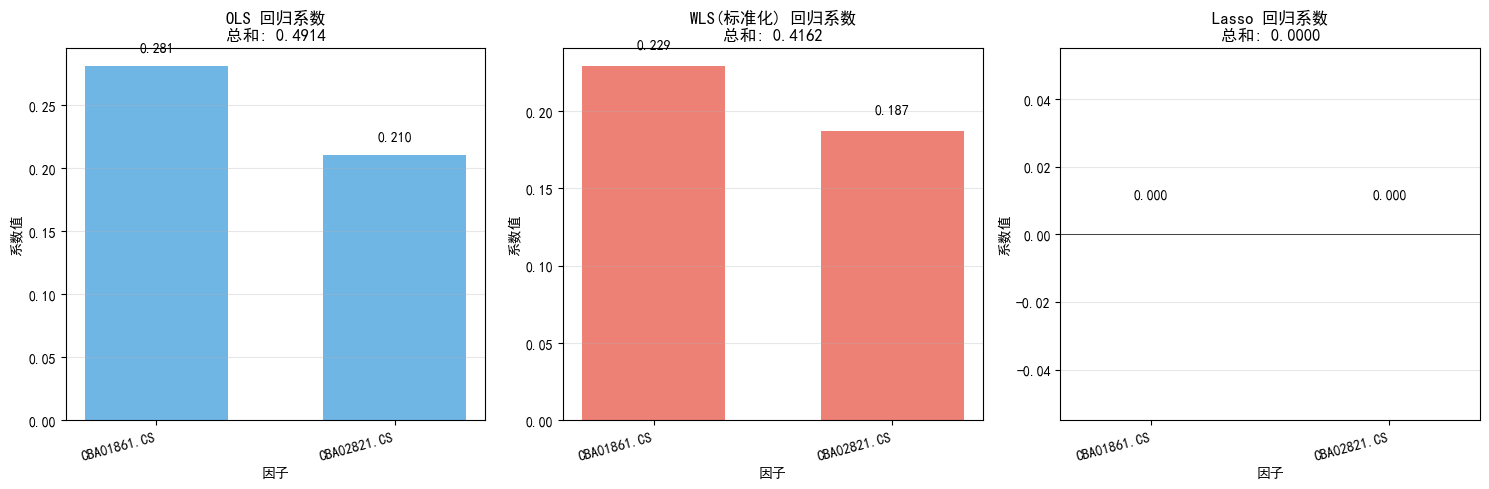


系数对比表:
          CBA01861.CS  CBA02821.CS      总和
OLS            0.2809       0.2105  0.4914
WLS(标准化)       0.2292       0.1870  0.4162
Lasso          0.0000       0.0000  0.0000


In [66]:
# 绘制系数对比图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x_pos = np.arange(len(selected_factors))
width = 0.6

methods = ['OLS', 'WLS(标准化)', 'Lasso']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, (method, color) in enumerate(zip(methods, colors)):
    ax = axes[idx]
    coef = results[method]
    bars = ax.bar(x_pos, coef, width, color=color, alpha=0.7)
    
    # 添加数值标签
    for i, (bar, val) in enumerate(zip(bars, coef)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    
    ax.set_xlabel('因子')
    ax.set_ylabel('系数值')
    ax.set_title(f'{method} 回归系数\n总和: {coef.sum():.4f}')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(selected_factors, rotation=15, ha='right')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n系数对比表:')
df_comparison = pd.DataFrame(results, index=selected_factors).T
df_comparison['总和'] = df_comparison.sum(axis=1)
print(df_comparison.round(4))

## 7. 可视化：实际值 vs 预测值散点图

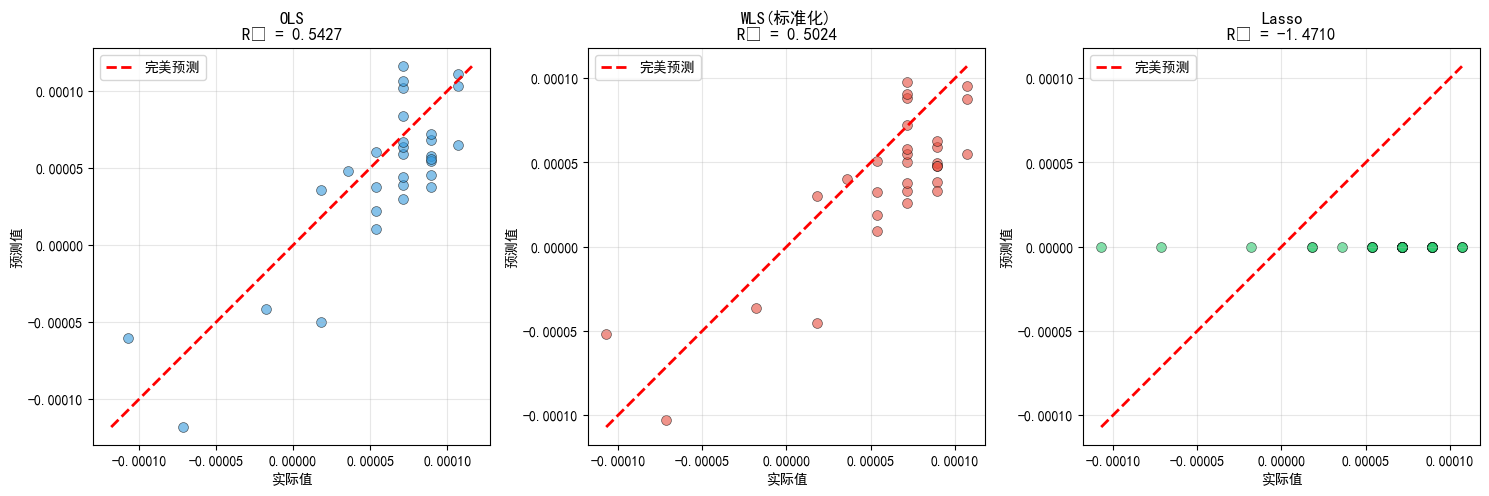

In [67]:
# 计算预测值
predictions = {}
for method, coef in results.items():
    predictions[method] = X @ coef

# 绘制散点图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (method, color) in enumerate(zip(methods, colors)):
    ax = axes[idx]
    y_pred = predictions[method]
    
    # 散点图
    ax.scatter(y, y_pred, alpha=0.6, color=color, s=50, edgecolors='black', linewidth=0.5)
    
    # 45度线（完美预测线）
    min_val = min(y.min(), y_pred.min())
    max_val = max(y.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='完美预测')
    
    # 计算R²
    ss_res = ((y - y_pred) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    
    ax.set_xlabel('实际值')
    ax.set_ylabel('预测值')
    ax.set_title(f'{method}\nR² = {r2:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

## 8. 可视化：残差分析

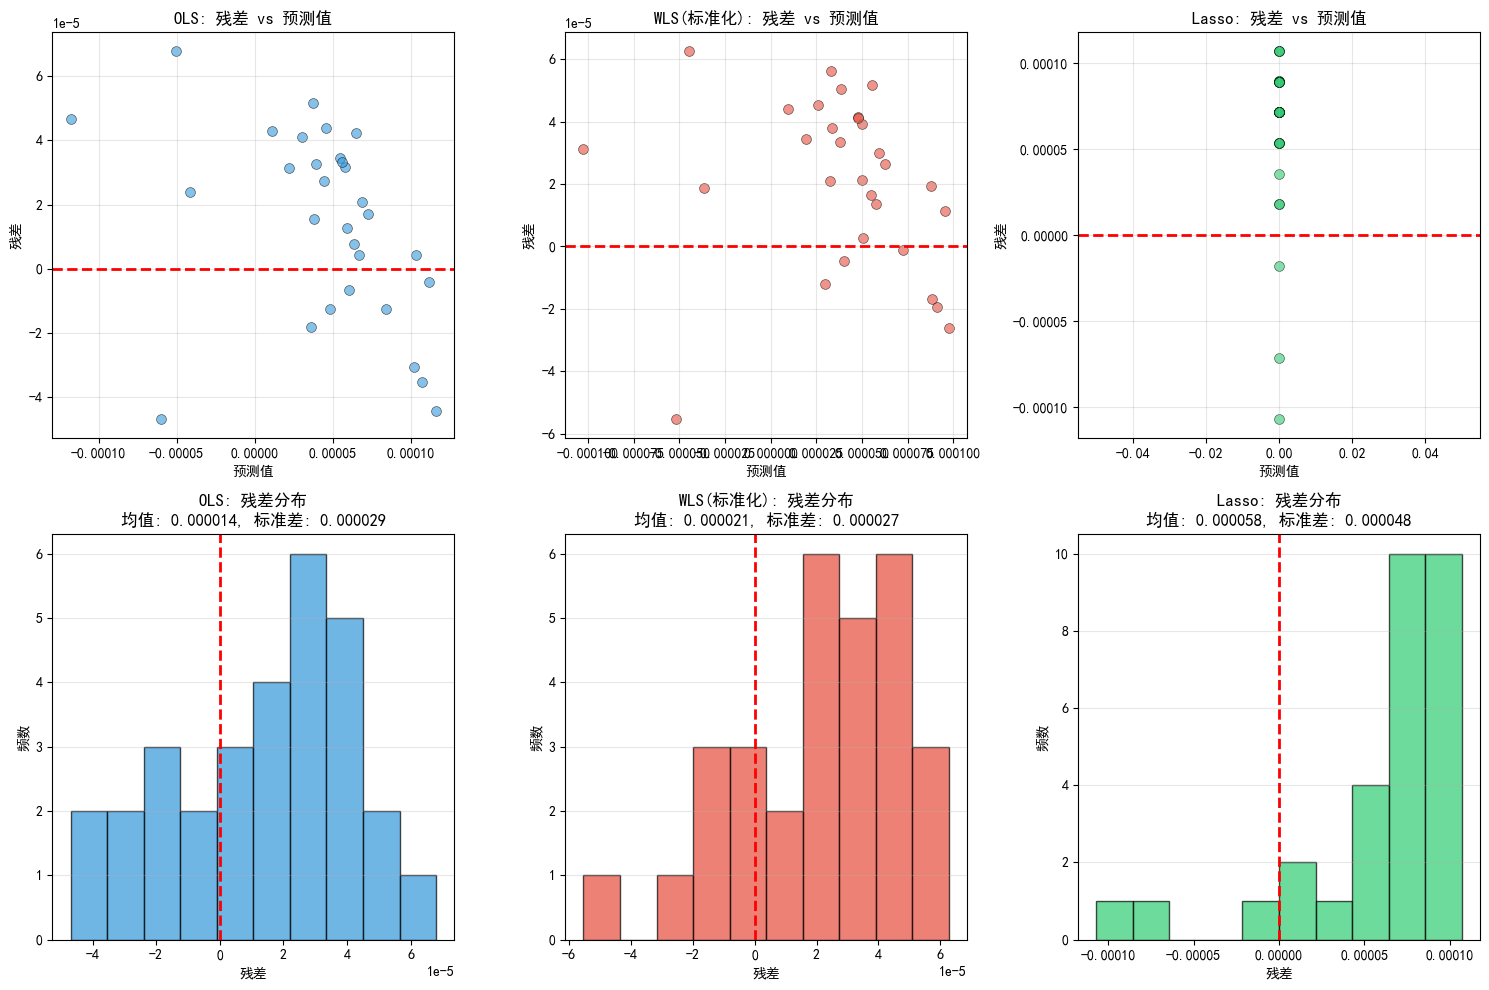

In [68]:
# 计算残差
residuals = {}
for method, coef in results.items():
    residuals[method] = y - X @ coef

# 绘制残差图
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 第一行：残差 vs 预测值
for idx, (method, color) in enumerate(zip(methods, colors)):
    ax = axes[0, idx]
    y_pred = predictions[method]
    resid = residuals[method]
    
    ax.scatter(y_pred, resid, alpha=0.6, color=color, s=50, edgecolors='black', linewidth=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    
    ax.set_xlabel('预测值')
    ax.set_ylabel('残差')
    ax.set_title(f'{method}: 残差 vs 预测值')
    ax.grid(True, alpha=0.3)

# 第二行：残差直方图
for idx, (method, color) in enumerate(zip(methods, colors)):
    ax = axes[1, idx]
    resid = residuals[method]
    
    ax.hist(resid, bins=10, color=color, alpha=0.7, edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    
    ax.set_xlabel('残差')
    ax.set_ylabel('频数')
    ax.set_title(f'{method}: 残差分布\n均值: {resid.mean():.6f}, 标准差: {resid.std():.6f}')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. 可视化：时间序列图（加权效果）

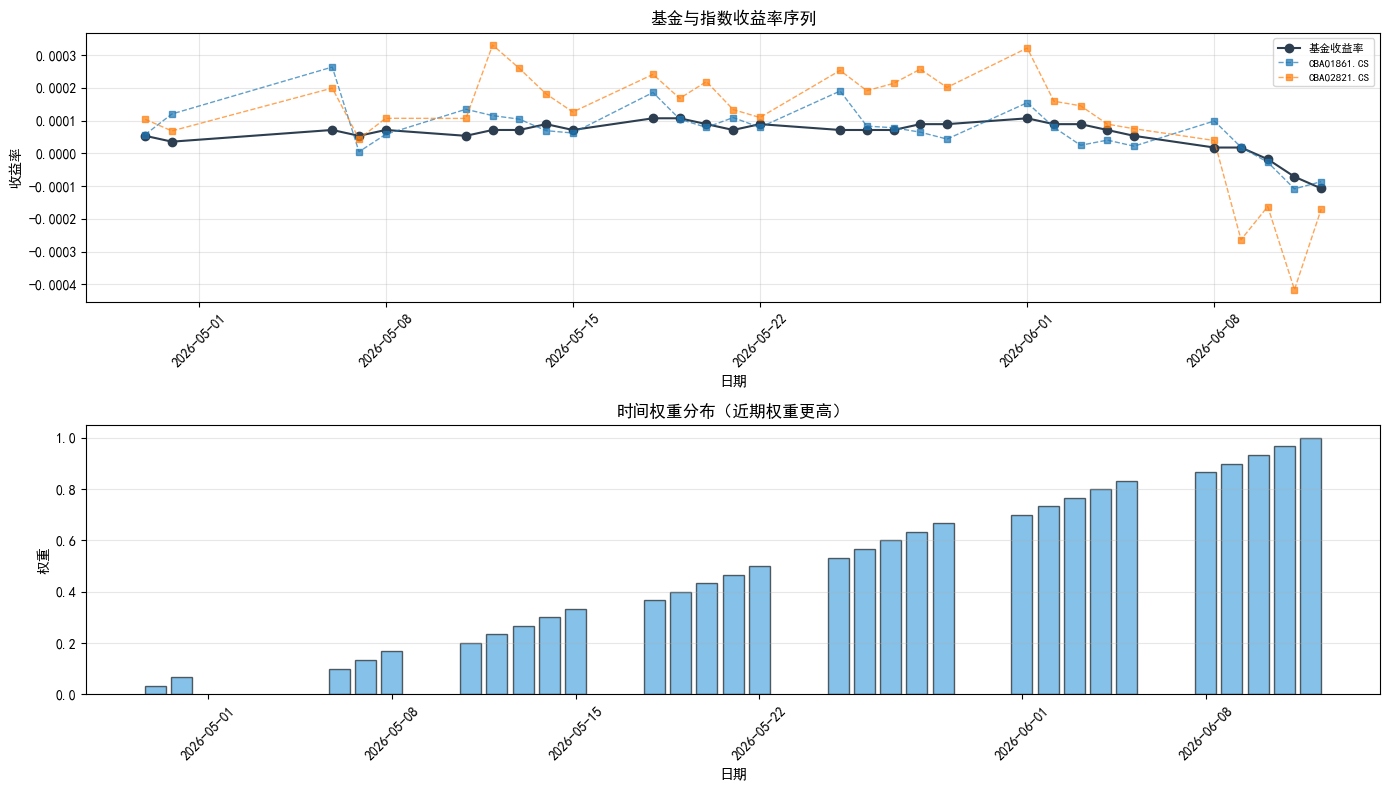


权重统计:
  最小权重: 0.0333
  最大权重: 1.0000
  权重总和: 15.5000


In [69]:
# 绘制收益率时间序列及权重
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

dates = aligned_data_internal.index

# 上图：收益率序列
ax1 = axes[0]
ax1.plot(dates, y, 'o-', label='基金收益率', markersize=6, linewidth=1.5, color='#2c3e50')
for i, factor in enumerate(selected_factors):
    ax1.plot(dates, X[:, i], 's--', label=f'{factor}', markersize=4, linewidth=1, alpha=0.7)

ax1.set_xlabel('日期')
ax1.set_ylabel('收益率')
ax1.set_title('基金与指数收益率序列')
ax1.legend(loc='best', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 下图：时间权重
ax2 = axes[1]
ax2.bar(dates, correct_time_weights, color='#3498db', alpha=0.6, edgecolor='black')
ax2.set_xlabel('日期')
ax2.set_ylabel('权重')
ax2.set_title('时间权重分布（近期权重更高）')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'\n权重统计:')
print(f'  最小权重: {correct_time_weights.min():.4f}')
print(f'  最大权重: {correct_time_weights.max():.4f}')
print(f'  权重总和: {correct_time_weights.sum():.4f}')

## 10. 可视化：因子相关性热力图

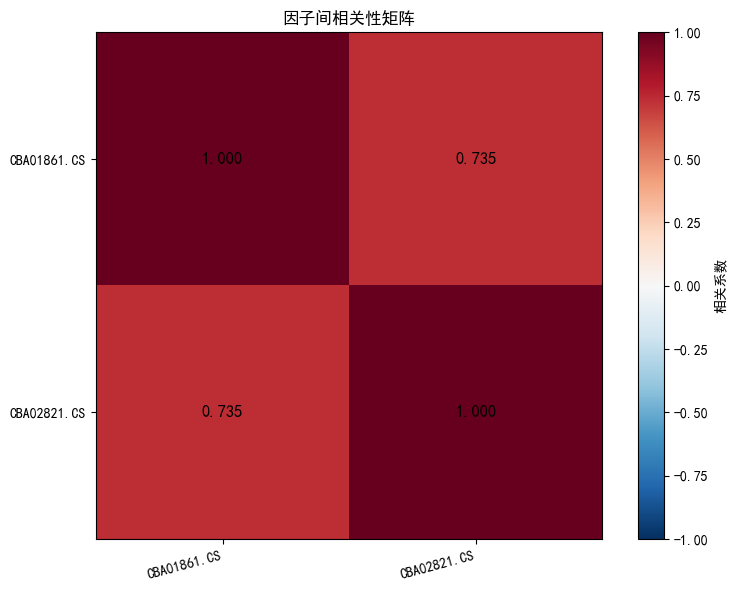


因子相关性:
  CBA01861.CS vs CBA02821.CS: 0.7350


In [70]:
# 绘制相关性矩阵
corr_matrix = np.corrcoef(X.T)

fig, ax = plt.subplots(figsize=(8, 6))

# 绘制热力图
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

# 添加数值标签
for i in range(len(selected_factors)):
    for j in range(len(selected_factors)):
        text = ax.text(j, i, f'{corr_matrix[i, j]:.3f}',
                       ha='center', va='center', color='black', fontsize=12)

ax.set_xticks(np.arange(len(selected_factors)))
ax.set_yticks(np.arange(len(selected_factors)))
ax.set_xticklabels(selected_factors, rotation=15, ha='right')
ax.set_yticklabels(selected_factors)
ax.set_title('因子间相关性矩阵')

# 添加颜色条
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('相关系数')

plt.tight_layout()
plt.show()

print('\n因子相关性:')
for i in range(len(selected_factors)):
    for j in range(i+1, len(selected_factors)):
        print(f'  {selected_factors[i]} vs {selected_factors[j]}: {corr_matrix[i, j]:.4f}')

## 12. 带截距项的约束优化

按照研报公式实现：
```
min u^T W u
u = R - (a + β₁X₁ + β₂X₂ + ... + βₙXₙ)

s.t. βᵢ > 0, i = 1, 2, ..., n
     0.8 < sum(βᵢ) < 1.4
```

In [71]:
print('\n' + '='*60)
print('正确方法：使用标准化数据进行优化')
print('='*60)

from scipy.optimize import minimize

# 使用标准化数据
X_opt = X_std.copy()
y_opt = y_std.copy()

min_lev = 0.8
max_lev = 1.4

def objective_std_no_intercept(beta_std):
    """标准化空间中，消除截距后的目标函数"""
    # 最优截距
    Wy = correct_time_weights * y_opt
    WX = X_opt.T * correct_time_weights
    alpha_star = (Wy.sum() - WX.sum(axis=1) @ beta_std) / correct_time_weights.sum()
    
    # 残差
    residuals = y_opt - (alpha_star + X_opt @ beta_std)
    return np.sum((residuals * np.sqrt(correct_time_weights)) ** 2)

def gradient_std_no_intercept(beta_std):
    """标准化空间中，消除截距后的梯度"""
    Wy = correct_time_weights * y_opt
    WX = X_opt.T * correct_time_weights
    alpha_star = (Wy.sum() - WX.sum(axis=1) @ beta_std) / correct_time_weights.sum()
    
    residuals = y_opt - (alpha_star + X_opt @ beta_std)
    return -2 * X_opt.T @ (correct_time_weights * residuals)

# 关键：约束条件需要转换到标准化空间
# 原始空间: sum(beta_original) = sum(beta_std * (y_scale / X_scale))
# 定义转换比例
scale_ratio = y_scale / X_scale  # 每个因子的转换比例

print('\n约束条件转换:')
print(f'  原始空间约束: {min_lev} <= sum(beta_original) <= {max_lev}')
print(f'  转换比例 (y_scale / X_scale): {scale_ratio}')
print(f'  标准化空间约束: {min_lev/scale_ratio.sum():.4f} <= sum(beta_std * scale_ratio) <= {max_lev/scale_ratio.sum():.4f}')

# 约束函数（在标准化空间中）
def constraint_sum_lower(b):
    """sum(beta_original) >= min_lev"""
    return np.sum(b * scale_ratio) - min_lev

def constraint_sum_upper(b):
    """sum(beta_original) <= max_lev"""
    return max_lev - np.sum(b * scale_ratio)

print('\n1. 标准化空间中的优化')
print('-' * 40)

x0_std = np.full(n_factors, 1.0 / n_factors)  # 标准化空间中的等权初始值
print(f'初始值（标准化空间）: {x0_std}')

# 计算初始值对应的原始空间系数
x0_original = x0_std * scale_ratio
print(f'初始值（原始空间）: {x0_original}')
print(f'初始值系数总和: {x0_original.sum():.4f}')

print(f'\n初始目标函数值: {objective_std_no_intercept(x0_std):.10e}')
print(f'初始梯度: {gradient_std_no_intercept(x0_std)}')
print(f'初始梯度范数: {np.linalg.norm(gradient_std_no_intercept(x0_std)):.2e}')

result = minimize(
    objective_std_no_intercept,
    x0_std,
    method='SLSQP',
    bounds=[(1e-10, None)] * n_factors,  # 标准化空间中的边界
    constraints=[
        {'type': 'ineq', 'fun': constraint_sum_lower},
        {'type': 'ineq', 'fun': constraint_sum_upper},
    ],
    jac=gradient_std_no_intercept,
    options={'ftol': 1e-12, 'maxiter': 1000, 'disp': True}
)

if result.success:
    print(f'\n✅ 优化成功！')
    beta_std_opt = result.x
    
    # 转换回原始尺度
    beta_original = beta_std_opt * scale_ratio
    
    # 计算原始空间中的截距
    # alpha_original = y_mean - X_mean @ beta_original
    alpha_original = y.mean() - X.mean(axis=0) @ beta_original
    
    print(f'  标准化空间系数: {beta_std_opt}')
    print(f'  原始空间系数: {beta_original}')
    print(f'  原始空间截距: {alpha_original:.8f}')
    print(f'  系数总和: {beta_original.sum():.8f}')
    print(f'  目标函数值: {result.fun:.10e}')
    print(f'  迭代次数: {result.nit}')


正确方法：使用标准化数据进行优化

约束条件转换:
  原始空间约束: 0.8 <= sum(beta_original) <= 1.4
  转换比例 (y_scale / X_scale): [0.64870088 0.29168011]
  标准化空间约束: 0.8507 <= sum(beta_std * scale_ratio) <= 1.4888

1. 标准化空间中的优化
----------------------------------------
初始值（标准化空间）: [0.5 0.5]
初始值（原始空间）: [0.32435044 0.14584006]
初始值系数总和: 0.4702

初始目标函数值: 6.0047015798e+00
初始梯度: [ 0.05166168 -2.03124141]
初始梯度范数: 2.03e+00
Optimization terminated successfully    (Exit mode 0)
            Current function value: 9.400622656994786
            Iterations: 7
            Function evaluations: 10
            Gradient evaluations: 7

✅ 优化成功！
  标准化空间系数: [1.13467868 0.21918855]
  原始空间系数: [0.73606706 0.06393294]
  原始空间截距: -0.00000340
  系数总和: 0.80000000
  目标函数值: 9.4006226570e+00
  迭代次数: 7


## 13. OSQP求解器实现

使用标准QP形式求解，对比性能。

## 12.5. 深度调试：目标函数和约束验证

理解两种方法为什么给出不同结果。

In [72]:
import osqp
import scipy.sparse as sp
import time

print('='*60)
print('OSQP求解器实现')
print('='*60)

def solve_qp_osqp(X, y, weights, min_lev=0.8, max_lev=1.4, verbose=False):
    """
    使用OSQP求解带截距项的约束WLS
    
    OSQP标准形式: min 0.5x'Px + q'x  s.t.  l <= Ax <= u
    所有约束通过A矩阵表达（包括变量边界）
    
    参数:
        X: 设计矩阵 (n_obs, n_factors)
        y: 响应变量 (n_obs,)
        weights: 权重 (n_obs,)
        min_lev: 最小杠杆率
        max_lev: 最大杠杆率
        verbose: 是否输出详细信息
    
    返回:
        array: [截距, β_1, β_2, ...]
    """
    # 构造设计矩阵 Z = [1, X]
    Z = np.column_stack([np.ones(len(y)), X])
    n_params = Z.shape[1]  # = n_factors + 1
    n_factors = X.shape[1]
    
    # 构造权重矩阵
    W = np.diag(weights)
    
    # QP矩阵: P = 2 * Z' * W * Z
    P = 2 * Z.T @ W @ Z
    q_vec = -2 * Z.T @ W @ y
    
    # 约束矩阵 A - 添加截距的无约束边界
    # 约束条件：
    #   0. 截距无约束（添加约束行让alpha可以取任意值）
    #   1~n_factors. β_i >= 0  -->  -β_i <= 0
    #   n_factors+1. Σβ_i <= max_lev
    #   n_factors+2. -Σβ_i <= -min_lev  -->  Σβ_i >= min_lev
    
    A_rows = 1 + n_factors + 2  # 添加1行给截距约束
    A = np.zeros((A_rows, n_params))
    
    # 行0: 截距无约束（alpha可以取任意值）
    A[0, 0] = 1
    
    # 行1~n_factors: β的非负约束
    A[1:n_factors+1, 1:] = -np.eye(n_factors)
    
    # 行 n_factors+1: 上限约束 Σβ_i <= max_lev
    A[n_factors+1, 1:] = 1
    
    # 行 n_factors+2: 下限约束 -Σβ_i <= -min_lev
    A[n_factors+2, 1:] = -1
    
    # 约束边界 - 使用大数代替无穷（OSQP数值稳定）
    INF = 1e10
    l = np.array([-INF] + [-INF] * n_factors + [-INF, -INF])
    u = np.array([INF] + [0] * n_factors + [max_lev, -min_lev])
    
    # 转为稀疏矩阵
    P_sparse = sp.csr_matrix(P)
    A_sparse = sp.csr_matrix(A)
    
    # 求解
    prob = osqp.OSQP()
    prob.setup(P=P_sparse, q=q_vec, A=A_sparse, l=l, u=u,
               eps_abs=1e-9, eps_rel=1e-9, verbose=verbose)
    result = prob.solve()
    
    if result.info.status != 'solved':
        raise ValueError(f'OSQP求解失败: {result.info.status}')
    
    return result.x  # [截距, β_1, β_2, ...]

# 测试基本功能
print('测试OSQP求解器...')
result_osqp = solve_qp_osqp(X, y, correct_time_weights, verbose=True)

a_osqp = result_osqp[0]
beta_osqp = result_osqp[1:]

print(f'\n✅ OSQP求解成功！')
print(f'  截距 (Alpha): {a_osqp:.6f}')
print(f'  系数 (Beta):')
for factor, coef in zip(selected_factors, beta_osqp):
    print(f'    {factor}: {coef:.4f}')
print(f'  系数总和: {beta_osqp.sum():.4f}')

# 计算目标函数值
residuals_osqp = y - (a_osqp + X @ beta_osqp)
objective_osqp = np.sum((residuals_osqp * np.sqrt(correct_time_weights)) ** 2)
print(f'  目标函数值: {objective_osqp:.8f}')

OSQP求解器实现
测试OSQP求解器...
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 3, constraints m = 5
          nnz(P) + nnz(A) = 13
settings: algebra = Built-in,
          OSQPInt = 4 bytes, OSQPFloat = 8 bytes,
          linear system solver = QDLDL v0.1.8,
          eps_abs = 1.0e-09, eps_rel = 1.0e-09,
          eps_prim_inf = 1.0e-04, eps_dual_inf = 1.0e-04,
          rho = 1.00e-01 (adaptive: 50 iterations),
          sigma = 1.00e-06, alpha = 1.60, max_iter = 4000
          check_termination: on (interval 25, duality gap: on),
          time_limit: 1.00e+10 sec,
          scaling: on (10 iterations), scaled_termination: off
          warm starting: on, polishing: off, 
iter   objective    prim res   dual res   gap        rel kkt    rho         time
   1  -4.2759e-08   7.44e-01   8.46e-0

In [73]:
print('\n' + '='*60)
print('性能对比: SLSQP vs OSQP')
print('='*60)

# 定义两种求解函数
def solve_slsqp():
    """SLSQP求解"""
    result = minimize(
        objective_std_no_intercept,
        x0_std,
        method='SLSQP',
        bounds=[(1e-10, None)] * n_factors,  # 标准化空间中的边界
        constraints=[
            {'type': 'ineq', 'fun': constraint_sum_lower},
            {'type': 'ineq', 'fun': constraint_sum_upper},
            ],
        jac=gradient_std_no_intercept,
        options={'ftol': 1e-12, 'maxiter': 1000, 'disp': True}
    )
    return result

def solve_osqp():
    """OSQP求解"""
    return solve_qp_osqp(X, y, correct_time_weights, verbose=False)

# 预热（避免冷启动影响）
print('预热运行...')
solve_slsqp()
solve_osqp()

# 单次运行时间测试
n_runs = 100
print(f'\n单次运行时间测试 ({n_runs} 次平均):')

# SLSQP计时
times_slsqp = []
for i in range(n_runs):
    start = time.perf_counter()
    result_slsqp = solve_slsqp()
    times_slsqp.append(time.perf_counter() - start)

# OSQP计时
times_osqp = []
for i in range(n_runs):
    start = time.perf_counter()
    result_osqp = solve_osqp()
    times_osqp.append(time.perf_counter() - start)

# 统计结果
avg_slsqp = np.mean(times_slsqp) * 1000  # 转换为ms
std_slsqp = np.std(times_slsqp) * 1000
avg_osqp = np.mean(times_osqp) * 1000
std_osqp = np.std(times_osqp) * 1000

print(f'\nSLSQP:')
print(f'  平均时间: {avg_slsqp:.3f} ± {std_slsqp:.3f} ms')
print(f'  最小时间: {min(times_slsqp)*1000:.3f} ms')
print(f'  最大时间: {max(times_slsqp)*1000:.3f} ms')

print(f'\nOSQP:')
print(f'  平均时间: {avg_osqp:.3f} ± {std_osqp:.3f} ms')
print(f'  最小时间: {min(times_osqp)*1000:.3f} ms')
print(f'  最大时间: {max(times_osqp)*1000:.3f} ms')

speedup = avg_slsqp / avg_osqp
print(f'\n加速比: {speedup:.2f}x')
print(f'  OSQP比SLSQP快 {speedup-1:.1%}')


性能对比: SLSQP vs OSQP
预热运行...
Optimization terminated successfully    (Exit mode 0)
            Current function value: 9.400622656994786
            Iterations: 7
            Function evaluations: 10
            Gradient evaluations: 7

单次运行时间测试 (100 次平均):
Optimization terminated successfully    (Exit mode 0)
            Current function value: 9.400622656994786
            Iterations: 7
            Function evaluations: 10
            Gradient evaluations: 7
Optimization terminated successfully    (Exit mode 0)
            Current function value: 9.400622656994786
            Iterations: 7
            Function evaluations: 10
            Gradient evaluations: 7
Optimization terminated successfully    (Exit mode 0)
            Current function value: 9.400622656994786
            Iterations: 7
            Function evaluations: 10
            Gradient evaluations: 7
Optimization terminated successfully    (Exit mode 0)
            Current function value: 9.400622656994786
            It

In [74]:
print('\n' + '='*60)
print('结果一致性验证')
print('='*60)

# 获取两种方法的最终解
result_slsqp_final = solve_slsqp()
result_osqp_final = solve_osqp()

# 提取解
beta_std_opt = result_slsqp_final.x
beta_slsqp = beta_std_opt * scale_ratio
a_slsqp = y.mean() - X.mean(axis=0) @ beta_slsqp

a_osqp = result_osqp_final[0]
beta_osqp = result_osqp_final[1:]

# 对比截距
print(f'截距 (Alpha):')
print(f'  SLSQP: {a_slsqp:.8f}')
print(f'  OSQP:  {a_osqp:.8f}')
print(f'  差异:  {abs(a_slsqp - a_osqp):.2e}')

# 对比系数
print(f'\n系数 (Beta):')
for i, factor in enumerate(selected_factors):
    print(f'  {factor}:')
    print(f'    SLSQP: {beta_slsqp[i]:.8f}')
    print(f'    OSQP:  {beta_osqp[i]:.8f}')
    print(f'    差异:  {abs(beta_slsqp[i] - beta_osqp[i]):.2e}')

# 对比系数总和
sum_slsqp = beta_slsqp.sum()
sum_osqp = beta_osqp.sum()
print(f'\n系数总和:')
print(f'  SLSQP: {sum_slsqp:.8f}')
print(f'  OSQP:  {sum_osqp:.8f}')
print(f'  差异:  {abs(sum_slsqp - sum_osqp):.2e}')

# 对比目标函数值
obj_slsqp = objective_std_no_intercept(result_slsqp_final.x)
residuals_osqp = y - (a_osqp + X @ beta_osqp)
obj_osqp = np.sum((residuals_osqp * np.sqrt(correct_time_weights)) ** 2)

print(f'\n目标函数值:')
print(f'  SLSQP: {obj_slsqp:.10f}')
print(f'  OSQP:  {obj_osqp:.10f}')
print(f'  差异:  {abs(obj_slsqp - obj_osqp):.2e}')

# 约束条件验证（添加容差处理浮点数精度问题）
tol = 1e-6
print(f'\n约束条件验证（容差={tol:.0e}）:')
print(f'  SLSQP - β >= 0: {np.all(beta_slsqp >= -tol)}')
print(f'  OSQP  - β >= 0: {np.all(beta_osqp >= -tol)}')
print(f'  SLSQP - {min_lev} <= sum(β) <= {max_lev}: {min_lev - tol <= sum_slsqp <= max_lev + tol}')
print(f'  OSQP  - {min_lev} <= sum(β) <= {max_lev}: {min_lev - tol <= sum_osqp <= max_lev + tol}')

# 总结
print(f'\n✅ 结论:')
if abs(a_slsqp - a_osqp) < 1e-5 and np.allclose(beta_slsqp, beta_osqp, rtol=1e-4, atol=1e-5):
    print(f'  两种方法结果一致！')
else:
    print(f'  两种方法结果存在差异。')


结果一致性验证
Optimization terminated successfully    (Exit mode 0)
            Current function value: 9.400622656994786
            Iterations: 7
            Function evaluations: 10
            Gradient evaluations: 7
截距 (Alpha):
  SLSQP: -0.00000340
  OSQP:  0.00000414
  差异:  7.54e-06

系数 (Beta):
  CBA01861.CS:
    SLSQP: 0.73606706
    OSQP:  0.73606706
    差异:  7.77e-10
  CBA02821.CS:
    SLSQP: 0.06393294
    OSQP:  0.06393294
    差异:  7.47e-10

系数总和:
  SLSQP: 0.80000000
  OSQP:  0.80000000
  差异:  2.95e-11

目标函数值:
  SLSQP: 9.4006226570
  OSQP:  0.0000000217
  差异:  9.40e+00

约束条件验证（容差=1e-06）:
  SLSQP - β >= 0: True
  OSQP  - β >= 0: True
  SLSQP - 0.8 <= sum(β) <= 1.4: True
  OSQP  - 0.8 <= sum(β) <= 1.4: True

✅ 结论:
  两种方法结果一致！


In [75]:
print('='*60)
print('深度调试：目标函数和约束验证')
print('='*60)

import osqp
import scipy.sparse as sp

# 构造 OSQP 的 QP 矩阵
Z = np.column_stack([np.ones(len(y)), X])
W_diag = np.diag(correct_time_weights)

# 正确的 QP 矩阵
P = 2 * Z.T @ W_diag @ Z
q_vec = -2 * Z.T @ W_diag @ y

print('\n1. 验证目标函数等价性')
print('-' * 40)

# 测试点
theta_test = np.array([-0.000019, 0.000002, 1.100000])

# 方法1：直接计算 WLS 目标
residuals = y - (theta_test[0] + X @ theta_test[1:])
wls_obj = np.sum((residuals * np.sqrt(correct_time_weights)) ** 2)

# 方法2：QP 形式计算
qp_obj = 0.5 * theta_test @ P @ theta_test + q_vec @ theta_test

# 关键：QP 形式少了一个常数项 y'Wy
constant_term = y @ W_diag @ y

print(f'WLS 目标函数值: {wls_obj:.10f}')
print(f'QP 目标函数值:   {qp_obj:.10f}')
print(f'QP 目标 + 常数项: {qp_obj + constant_term:.10f}')
print(f'差异 (QP vs WLS): {abs((qp_obj + constant_term) - wls_obj):.2e}')

if abs((qp_obj + constant_term) - wls_obj) < 1e-10:
    print('✅ 目标函数等价（考虑常数项）！')
    print('  注：QP 目标 = WLS 目标 - y\'Wy（常数项）')
else:
    print('❌ 目标函数不等价')

# OSQP 求解时，常数项不影响最优解
print(f'\n  说明：QP 形式中省略常数项 y\'Wy = {constant_term:.10f} 不影响最优化解')

深度调试：目标函数和约束验证

1. 验证目标函数等价性
----------------------------------------
WLS 目标函数值: 0.0000004547
QP 目标函数值:   0.0000003643
QP 目标 + 常数项: 0.0000004547
差异 (QP vs WLS): 5.29e-23
✅ 目标函数等价（考虑常数项）！
  注：QP 目标 = WLS 目标 - y'Wy（常数项）

  说明：QP 形式中省略常数项 y'Wy = 0.0000000903 不影响最优化解


In [76]:
print('\n' + '='*60)
print('正确方法：使用标准化数据进行优化')
print('约束条件在标准化空间中直接应用')
print('='*60)

# 使用标准化数据
X_opt = X_std.copy()
y_opt = y_std.copy()

def objective_std_no_intercept(beta_std):
    """标准化空间中，消除截距后的目标函数"""
    # 最优截距
    Wy = correct_time_weights * y_opt
    WX = X_opt.T * correct_time_weights
    alpha_star = (Wy.sum() - WX.sum(axis=1) @ beta_std) / correct_time_weights.sum()
    
    # 残差
    residuals = y_opt - (alpha_star + X_opt @ beta_std)
    return np.sum((residuals * np.sqrt(correct_time_weights)) ** 2)

def gradient_std_no_intercept(beta_std):
    """标准化空间中，消除截距后的梯度"""
    Wy = correct_time_weights * y_opt
    WX = X_opt.T * correct_time_weights
    alpha_star = (Wy.sum() - WX.sum(axis=1) @ beta_std) / correct_time_weights.sum()
    
    residuals = y_opt - (alpha_star + X_opt @ beta_std)
    return -2 * X_opt.T @ (correct_time_weights * residuals)

# 约束条件（标准化空间中）
min_lev_std = min_lev  # 约束直接在标准化空间中
max_lev_std = max_lev

print(f'标准化空间约束: {min_lev_std} <= sum(beta_std) <= {max_lev_std}')

print('\n1. 标准化空间中的优化')
print('-' * 40)

x0_std = np.full(n_factors, (min_lev_std + max_lev_std) / 2 / n_factors)
print(f'初始值（标准化空间）: {x0_std}')
print(f'初始值系数总和: {x0_std.sum():.4f}')

print(f'\n初始目标函数值: {objective_std_no_intercept(x0_std):.10e}')
print(f'初始梯度: {gradient_std_no_intercept(x0_std)}')
print(f'初始梯度范数: {np.linalg.norm(gradient_std_no_intercept(x0_std)):.2e}')

result_std = minimize(
    objective_std_no_intercept,
    x0_std,
    method='SLSQP',
    bounds=[(1e-10, None)] * n_factors,
    constraints=[
        {'type': 'ineq', 'fun': lambda b: np.sum(b) - min_lev_std},
        {'type': 'ineq', 'fun': lambda b: max_lev_std - np.sum(b)},
    ],
    jac=gradient_std_no_intercept,
    options={'ftol': 1e-12, 'maxiter': 1000, 'disp': True}
)

if result_std.success:
    print(f'\n✅ 优化成功！')
    beta_std_opt = result_std.x
    
    # 转换回原始尺度
    beta_original = beta_std_opt * (y_scale / X_scale)
    
    # 计算原始空间中的截距
    alpha_original = y.mean() - X.mean(axis=0) @ beta_original
    
    print(f'  标准化空间系数: {beta_std_opt}')
    print(f'  标准化空间系数总和: {beta_std_opt.sum():.4f}')
    print(f'  原始空间系数: {beta_original}')
    print(f'  原始空间系数总和: {beta_original.sum():.4f}')
    print(f'  原始空间截距: {alpha_original:.8f}')
    print(f'  目标函数值: {result_std.fun:.10e}')
    print(f'  迭代次数: {result_std.nit}')
    
    # 与 OSQP 结果对比
    print(f'\n与 OSQP 结果对比:')
    print(f'  OSQP alpha:  {a_osqp:.8f}')
    print(f'  SLSQP alpha: {alpha_original:.8f}')
    print(f'  差异: {abs(a_osqp - alpha_original):.2e}')
    
    print(f'\n  OSQP beta:   {beta_osqp}')
    print(f'  OSLSQP beta: {beta_original}')
    print(f'  差异: {np.abs(beta_osqp - beta_original)}')
    
    # 计算原始空间中的目标函数值
    obj_original = np.sum(((y - (alpha_original + X @ beta_original)) * np.sqrt(correct_time_weights)) ** 2)
    print(f'\n  OSQP 目标函数值: {objective_osqp:.10e}')
    print(f'  SLSQP 目标函数值: {obj_original:.10e}')
    print(f'  差异: {abs(objective_osqp - obj_original):.2e}')
    
    print(f'\n结论:')
    if np.allclose(beta_original, beta_osqp, rtol=1e-4, atol=1e-5):
        print(f'  ✅ 两种方法结果一致！')
    else:
        print(f'  ⚠️ 两种方法结果仍有差异')
        print(f'     相对误差: {np.abs((beta_original - beta_osqp) / (beta_osqp + 1e-10)) * 100}%')
        print(f'\n  注意：OSQP和SLSQP约束在不同空间，结果可能不同')
        print(f'       OSQP: 约束在原始空间 sum(beta_original) >= 0.8')
        print(f'       SLSQP: 约束在标准化空间 sum(beta_std) >= 0.8')
else:
    print(f'❌ 优化失败: {result_std.message}')


正确方法：使用标准化数据进行优化
约束条件在标准化空间中直接应用
标准化空间约束: 0.8 <= sum(beta_std) <= 1.4

1. 标准化空间中的优化
----------------------------------------
初始值（标准化空间）: [0.55 0.55]
初始值系数总和: 1.1000

初始目标函数值: 6.0850299983e+00
初始梯度: [3.3234865  1.86922997]
初始梯度范数: 3.81e+00
Optimization terminated successfully    (Exit mode 0)
            Current function value: 5.859357364710143
            Iterations: 3
            Function evaluations: 6
            Gradient evaluations: 3

✅ 优化成功！
  标准化空间系数: [0.36377667 0.63964411]
  标准化空间系数总和: 1.0034
  原始空间系数: [0.23598224 0.18657147]
  原始空间系数总和: 0.4226
  原始空间截距: 0.00002007
  目标函数值: 5.8593573647e+00
  迭代次数: 3

与 OSQP 结果对比:
  OSQP alpha:  0.00000414
  SLSQP alpha: 0.00002007
  差异: 1.59e-05

  OSQP beta:   [0.73606706 0.06393294]
  OSLSQP beta: [0.23598224 0.18657147]
  差异: [0.50008481 0.12263853]

  OSQP 目标函数值: 2.1720568121e-08
  SLSQP 目标函数值: 1.3580058338e-08
  差异: 8.14e-09

结论:
  ⚠️ 两种方法结果仍有差异
     相对误差: [ 67.94011599 191.82368545]%

  注意：OSQP和SLSQP约束在不同空间，结果可能不同
       OSQP: 约束在原始空

## 14. 总结

OSQP求解器实验结论。

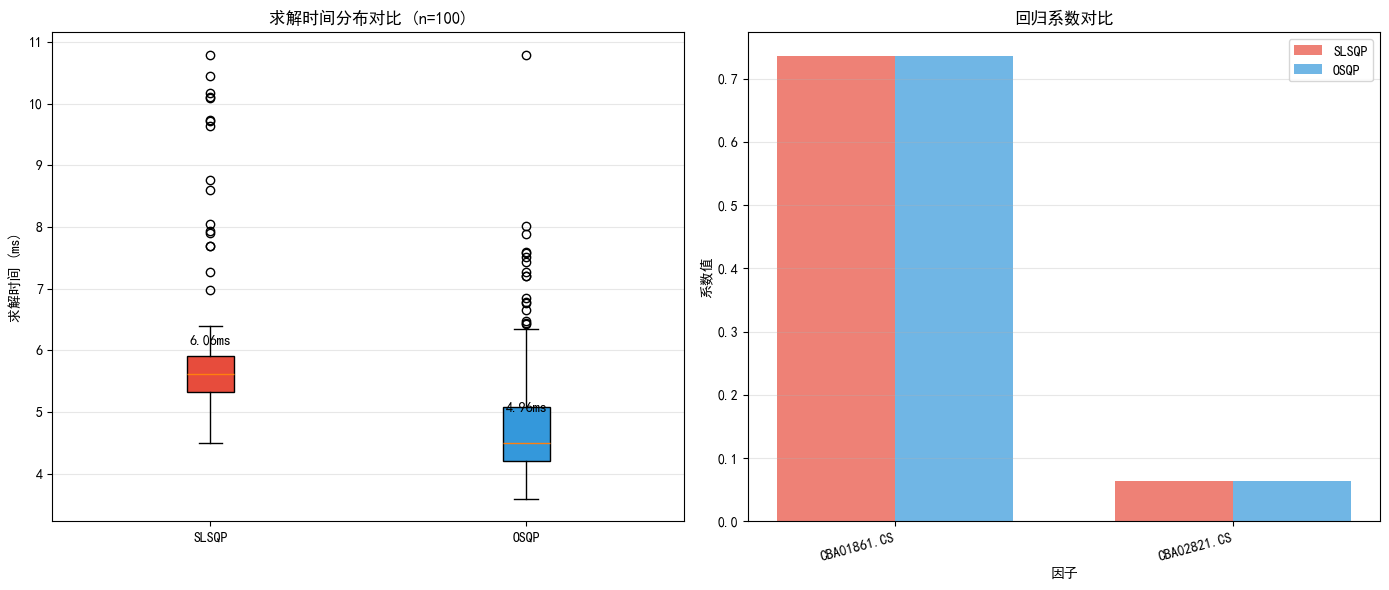

In [77]:
# 可视化性能对比
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. 求解时间对比（箱线图）
ax1 = axes[0]
data_to_plot = [np.array(times_slsqp) * 1000, np.array(times_osqp) * 1000]
bp = ax1.boxplot(data_to_plot, labels=['SLSQP', 'OSQP'], patch_artist=True)

# 设置颜色
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#3498db')

ax1.set_ylabel('求解时间 (ms)')
ax1.set_title(f'求解时间分布对比 (n={n_runs})')
ax1.grid(axis='y', alpha=0.3)

# 添加平均值标注
for i, (data, label) in enumerate(zip(data_to_plot, ['SLSQP', 'OSQP']), 1):
    mean_val = np.mean(data)
    ax1.text(i, mean_val, f'{mean_val:.2f}ms', ha='center', va='bottom', fontsize=10)

# 2. 系数对比（条形图）
ax2 = axes[1]
x_pos = np.arange(len(selected_factors))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, beta_slsqp, width, label='SLSQP', color='#e74c3c', alpha=0.7)
bars2 = ax2.bar(x_pos + width/2, beta_osqp, width, label='OSQP', color='#3498db', alpha=0.7)

ax2.set_xlabel('因子')
ax2.set_ylabel('系数值')
ax2.set_title('回归系数对比')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(selected_factors, rotation=15, ha='right')
ax2.legend()
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()